<a href="https://colab.research.google.com/github/priyakumar88380/Healthcare-Patient-Billing-Analysis/blob/main/Diabet_clean_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('diabetes.csv')

In [4]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            2      138             62             35        0  33.6   
1            0       84             82             31      125  38.2   
2            0      145              0              0        0  44.2   
3            0      135             68             42      250  42.3   
4            1      139             62             41      480  40.7   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.127   47        1  
1                     0.233   23        0  
2                     0.630   31        1  
3                     0.365   24        1  
4                     0.536   21        0  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB
None


In [6]:
zero_columns=['Glucose','BloodPressure','SkinThickness','Insulin ','BMI']

In [8]:
df.columns=df.columns.str.strip()

In [17]:
print("Raw columns:", repr(df.columns.tolist()))
df.columns = [
    'Pregnancies', 'Glucose', 'BloodPres', 'SkinThickr',
    'Insulin', 'BMI', 'DiabetesP', 'Age', 'Outcome']
print("New clean columns:", df.columns.tolist())


Raw columns: ['Pregnancies', 'Glucose', 'BloodPres', 'SkinThickr', 'Insulin', 'BMI', 'DiabetesP', 'Age', 'Outcome']
New clean columns: ['Pregnancies', 'Glucose', 'BloodPres', 'SkinThickr', 'Insulin', 'BMI', 'DiabetesP', 'Age', 'Outcome']


In [16]:
zero_columns = ['Glucose', 'BloodPres', 'SkinThickr', 'Insulin', 'BMI']
df[zero_columns] = df[zero_columns].replace(0,np.nan)
for col in zero_columns:
  df[col] = df[col].fillna(df[col].median())

print("Data cleaning sucessfull!")

Data cleaning sucessfull!


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df.drop(columns=['Outcome'])
y=df['Outcome']

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
scaler = StandardScaler()

In [23]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [24]:
print("Data splitting and feature scaling complete!")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Data splitting and feature scaling complete!
Training set shape: (1600, 8)
Testing set shape: (400, 8)


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [28]:
model = RandomForestClassifier(random_state=42,n_estimators=100)
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)
print(f"Model Training Complete!")
print(f"Overall Accuracy Score: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

Model Training Complete!
Overall Accuracy Score: 98.50%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       263
           1       0.98      0.98      0.98       137

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



In [29]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows in dataset: {duplicates}")

Number of duplicate rows in dataset: 1256


In [30]:
y_train_pred = model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train,y_train_pred)
print(f"Training Accuracy Score: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy Score: {accuracy * 100:.2f}%")

Training Accuracy Score: 100.00%
Testing Accuracy Score: 98.50%


In [31]:
if duplicates > 0:
  print("\nRecommendation: We should drop duplicates and retrain the model.")


Recommendation: We should drop duplicates and retrain the model.


In [32]:
df_clean = df.drop_duplicates()
print(f"Rows remaining after removing duplicates: {df_clean.shape[0]}")

Rows remaining after removing duplicates: 744


In [37]:
final_df = df.drop_duplicates()
X_final = final_df.drop(columns=['Outcome'])
y_final = final_df['Outcome']
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)
final_scaler = StandardScaler()
X_train_scaled_f = final_scaler.fit_transform(X_train_f)
X_test_scaled_f = final_scaler.transform(X_test_f)
final_model = RandomForestClassifier(random_state=42, n_estimators=100)
final_model.fit(X_train_scaled_f, y_train_f)
y_pred_f = final_model.predict(X_test_scaled_f)
final_accuracy = accuracy_score(y_test_f, y_pred_f)
print(f"Clean rows remaining: {final_df.shape[0]}")
print(f"Final Real Accuracy Score: {final_accuracy * 100:.2f}%")
print("\nFinal Classification Report:")
print(classification_report(y_test_f, y_pred_f))

Clean rows remaining: 744
Final Real Accuracy Score: 77.18%

Final Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.83        98
           1       0.71      0.57      0.63        51

    accuracy                           0.77       149
   macro avg       0.75      0.72      0.73       149
weighted avg       0.77      0.77      0.76       149



In [38]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}


In [39]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [44]:
grid_search.fit(X_train_scaled_f, y_train_f)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', None],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [41]:
best_model = grid_search.best_estimator_

In [42]:
y_pred_tuned = best_model.predict(X_test_scaled_f)
tuned_accuracy = accuracy_score(y_test_f, y_pred_tuned)

In [43]:
print(f"\nTuned Model Accuracy Score: {tuned_accuracy * 100:.2f}%")
print(f"Best Parameters Found: {grid_search.best_params_}")
print("\nTuned Classification Report:")
print(classification_report(y_test_f, y_pred_tuned))


Tuned Model Accuracy Score: 78.52%
Best Parameters Found: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        98
           1       0.67      0.73      0.70        51

    accuracy                           0.79       149
   macro avg       0.76      0.77      0.77       149
weighted avg       0.79      0.79      0.79       149



In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
importances = best_model.feature_importances_
feature_names = X_final.columns

feature_df = pd.DataFrame({
    'Medical Feature': feature_names,
    'Importance Score': importances
}).sort_values(by='Importance Score', ascending=False)

Text(0, 0.5, 'Medical Feature')

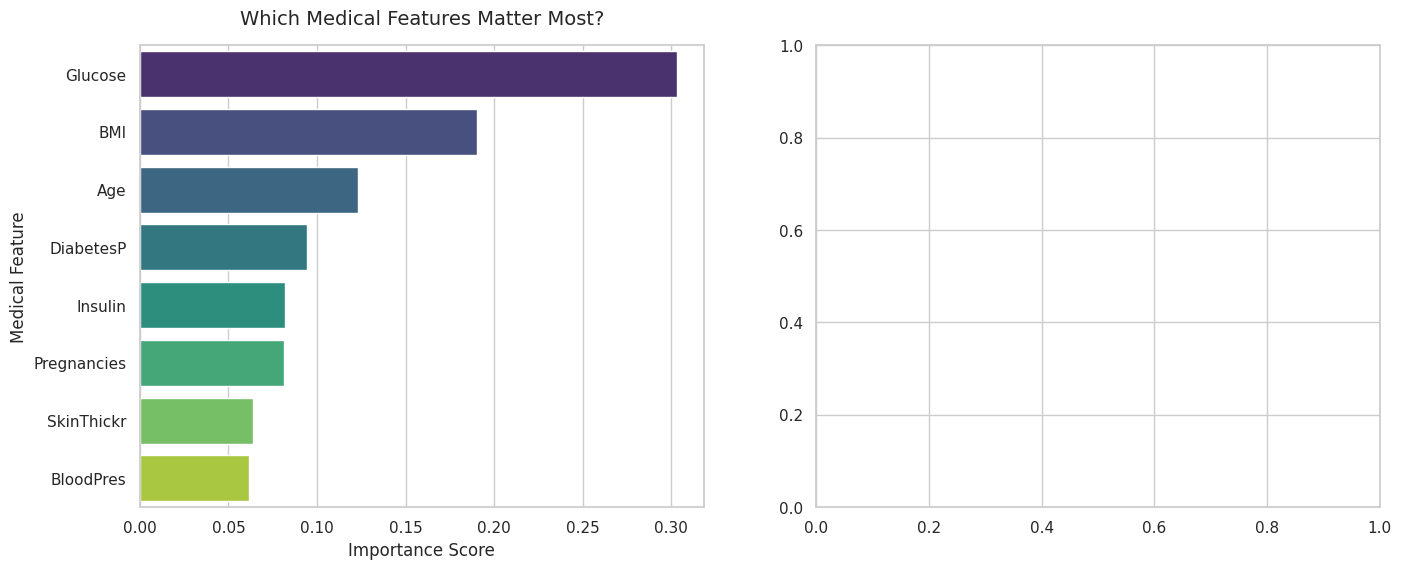

In [51]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    ax=axes[0],
    x='Importance Score',
    y='Medical Feature',
    data=feature_df,
    palette='viridis',
    hue='Medical Feature',
    legend=False
)
axes[0].set_title('Which Medical Features Matter Most?', fontsize=14, pad=15)
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_ylabel('Medical Feature', fontsize=12)


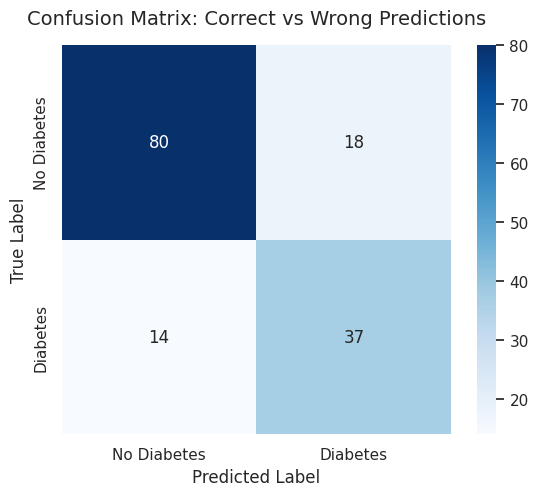

In [57]:
from sklearn.metrics import confusion_matrix
sns.set_theme(style="white")
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_f, y_pred_tuned)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes'],
    cbar=True,
    square=True
)
plt.title('Confusion Matrix: Correct vs Wrong Predictions', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

In [58]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train_scaled_f, y_train_f)
y_pred_dt = dt_model.predict(X_test_scaled_f)
dt_accuracy = accuracy_score(y_test_f, y_pred_dt)
print(f"Decision Tree Accuracy Score: {dt_accuracy * 100:.2f}%")
print("\nDecision Tree Classification Report:")
print(classification_report(y_test_f, y_pred_dt))

Decision Tree Accuracy Score: 73.83%

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.74      0.79        98
           1       0.60      0.73      0.65        51

    accuracy                           0.74       149
   macro avg       0.72      0.74      0.72       149
weighted avg       0.76      0.74      0.74       149



In [60]:
import xgboost as xgb
num_neg = (y_train_f == 0).sum()
num_pos = (y_train_f == 1).sum()
scale_weight = num_neg / num_pos
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    random_state=42
)
xgb_model.fit(X_train_scaled_f, y_train_f)
y_pred_xgb = xgb_model.predict(X_test_scaled_f)
xgb_accuracy = accuracy_score(y_test_f, y_pred_xgb)
print(f"XGBoost Accuracy Score: {xgb_accuracy * 100:.2f}%")
print("\nXGBoost Classification Report:")
print(classification_report(y_test_f, y_pred_xgb))

XGBoost Accuracy Score: 71.81%

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.74      0.78        98
           1       0.58      0.67      0.62        51

    accuracy                           0.72       149
   macro avg       0.69      0.71      0.70       149
weighted avg       0.73      0.72      0.72       149



In [62]:
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=5, class_weight='balanced', random_state=42)
dt_gini.fit(X_train_scaled_f, y_train_f)
y_pred_gini = dt_gini.predict(X_test_scaled_f)
gini_acc = accuracy_score(y_test_f, y_pred_gini)
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=5, class_weight='balanced', random_state=42)
dt_entropy.fit(X_train_scaled_f, y_train_f)
y_pred_entropy = dt_entropy.predict(X_test_scaled_f)
entropy_acc = accuracy_score(y_test_f, y_pred_entropy)

In [63]:
print("=== Split Criteria Comparison ===")
print(f"Gini Criterion Accuracy:    {gini_acc * 100:.2f}%")
print(f"Entropy Criterion Accuracy: {entropy_acc * 100:.2f}%\n")
print("--- Gini Classification Report ---")
print(classification_report(y_test_f, y_pred_gini))
print("--- Entropy Classification Report ---")
print(classification_report(y_test_f, y_pred_entropy))

=== Split Criteria Comparison ===
Gini Criterion Accuracy:    73.83%
Entropy Criterion Accuracy: 70.47%

--- Gini Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.74      0.79        98
           1       0.60      0.73      0.65        51

    accuracy                           0.74       149
   macro avg       0.72      0.74      0.72       149
weighted avg       0.76      0.74      0.74       149

--- Entropy Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.67      0.75        98
           1       0.55      0.76      0.64        51

    accuracy                           0.70       149
   macro avg       0.70      0.72      0.69       149
weighted avg       0.74      0.70      0.71       149

